# 미션 16 Modeling Part

- 기본 모델: `ahnhs2k/qtranslator_1.7b_v2`(Qwen3 1.7B 기반 한일 번역 자체 훈련 모델)
- 링크: [허깅페이스 모델 카드](https://huggingface.co/ahnhs2k/qtranslator_1.7b_v2)
- 목표 산출물
  - `qtranslator_1.7b_v2.pth`
  - `qtranslator_1.7b_v2_quantized.pth`
  - `qtranslator_1.7b_v2.onnx`
- 검증: PyTorch/ONNX 추론 결과 비교 + 간단 평가 데이터셋 성능 확인

## 1) 환경 준비

In [12]:
# 라이브러리 임포트
import os
import json
import time
import random
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModelForCausalLM
from huggingface_hub import snapshot_download

## 2) 환경 설정

In [ ]:
# 기본 환경 설정
@dataclass
class Config:
    # 모델과 결과물 저장 경로 설정
    project_dir = Path.cwd().parent
    model_dir = project_dir / "models" / "qtranslator_1.7b_v2"
    output_dir = project_dir / "models" / "m16"

    model_repo = "ahnhs2k/qtranslator_1.7b_v2"
    model_name = "qtranslator_1.7b_v2"

    # 미션 제출 규칙 mission_16_{model_name}.pth / .onnx로 저장
    pth_path = output_dir / f"mission_16_{model_name}.pth"
    pth_quant_path = output_dir / f"mission_16_{model_name}_quantized.pth"
    onnx_path = output_dir / f"mission_16_{model_name}.onnx"

    # 시드 고정
    seed = 42
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    # 디바이스 설정
    device = "cuda" if torch.cuda.is_available() else "cpu"

    def __post_init__(self):
        self.model_dir.parent.mkdir(parents=True, exist_ok=True)
        self.output_dir.mkdir(parents=True, exist_ok=True)


In [14]:
cfg = Config()
print("device:", cfg.device)
print("model_dir:", cfg.model_dir)
print("output_dir:", cfg.output_dir)
print("pth:", cfg.pth_path)
print("pth_quant:", cfg.pth_quant_path)
print("onnx:", cfg.onnx_path)


device: cuda
model_dir: /home/hosung/pytorch-demo/Mission_Archive/Codeit_Mission/models/qtranslator_1.7b_v2
output_dir: /home/hosung/pytorch-demo/Mission_Archive/Codeit_Mission/models/m16
pth: /home/hosung/pytorch-demo/Mission_Archive/Codeit_Mission/models/m16/mission_16_qtranslator_1.7b_v2.pth
pth_quant: /home/hosung/pytorch-demo/Mission_Archive/Codeit_Mission/models/m16/mission_16_qtranslator_1.7b_v2_quantized.pth
onnx: /home/hosung/pytorch-demo/Mission_Archive/Codeit_Mission/models/m16/mission_16_qtranslator_1.7b_v2.onnx


## 2-1) 모델 다운로드

In [6]:
# qtranslator 모델 다운로드
if cfg.model_dir.exists() and any(cfg.model_dir.iterdir()):
    print(f"이미 모델이 존재합니다. 다운로드 생략: {cfg.model_dir}")
else:
    print(f"다운로드 시작: {cfg.model_repo}")
    snapshot_download(
        repo_id=cfg.model_repo,
        local_dir=cfg.model_dir.as_posix(),
        local_dir_use_symlinks=False,
    )
    print(f"다운로드 완료: {cfg.model_dir}")


이미 모델이 존재합니다. 다운로드 생략: /home/hosung/pytorch-demo/Mission_Archive/Codeit_Mission/models/qtranslator_1.7b_v2


## 3) 모델 로드

In [21]:
# 모델과 토크나이저 로드
tokenizer = AutoTokenizer.from_pretrained(cfg.model_dir, trust_remote_code=True)

# ONNX export 호환성을 위해 float32 로드
model = AutoModelForCausalLM.from_pretrained(
    cfg.model_dir,
    torch_dtype=torch.float32,
    trust_remote_code=True,
)
model.eval()

print(type(model).__name__)
# numel()로 전체 원소 개수 계산
print("params:", f"{sum(p.numel() for p in model.parameters()):,}")


The tokenizer you are loading from '/home/hosung/pytorch-demo/Mission_Archive/Codeit_Mission/models/qtranslator_1.7b_v2' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForCausalLM
params: 1,720,574,976


## 4) `.pth` 저장 (기본 Pytorch 버전)

In [8]:
# 허깅페이스 모델 state_dict 저장
torch.save({
    "model_name": cfg.model_name,
    "format": "pytorch_state_dict",
    "state_dict": model.state_dict(),
}, cfg.pth_path)

print("Saved:", cfg.pth_path)


Saved: /home/hosung/pytorch-demo/Mission_Archive/Codeit_Mission/models/m16/mission_16_qtranslator_1.7b_v2.pth


## 5) `.pth` 저장 (양자화 버전: Dynamic INT8)

- LLM을 PTQ 방식으로 양자화
- CPU Dynamic Quantization 기반 `.pth`를 생성

In [9]:
# 모델 동적 양자화(int8)
quantized_model = torch.quantization.quantize_dynamic(
    model,
    {nn.Linear},
    dtype=torch.qint8,
)
quantized_model.eval()

torch.save({
    "model_name": cfg.model_name,
    "format": "pytorch_dynamic_quantized_state_dict",
    "dtype": "qint8",
    "state_dict": quantized_model.state_dict(),
}, cfg.pth_quant_path)

print("Saved:", cfg.pth_quant_path)


/tmp/ipykernel_32563/1955592679.py:2: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = torch.quantization.quantize_dynamic(


Saved: /home/hosung/pytorch-demo/Mission_Archive/Codeit_Mission/models/m16/mission_16_qtranslator_1.7b_v2_quantized.pth


## 6) ONNX 변환

- `input_ids`, `attention_mask`를 입력으로 받아 `logits`를 출력하는 래퍼를 추출

In [ ]:
# ONNX export를 위한 래퍼 모델 정의
class CausalLMLogitsWrapper(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model

    def forward(self, input_ids, attention_mask):
        outputs = self.base_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            use_cache=False,
        )
        return outputs.logits

wrapper = CausalLMLogitsWrapper(model).eval()

# ONNX export를 위한 더미 샘플 텍스트
sample_text = "난 네가 없으면 아무것도 못 해. 하지만 그걸 인정하고 싶지 않아."
enc = tokenizer(sample_text, return_tensors="pt", padding=False)
input_ids = enc["input_ids"].to(torch.long)
attention_mask = enc["attention_mask"].to(torch.long)

with torch.no_grad():
    torch.onnx.export(
        wrapper,
        (input_ids, attention_mask),
        cfg.onnx_path.as_posix(),
        input_names=["input_ids", "attention_mask"],
        output_names=["logits"],
        dynamic_axes={
            "input_ids": {0: "batch", 1: "seq"},
            "attention_mask": {0: "batch", 1: "seq"},
            "logits": {0: "batch", 1: "seq"},
        },
        opset_version=18,
        do_constant_folding=True,
    )

print("Saved:", cfg.onnx_path)


/tmp/ipykernel_32563/2101266752.py:23: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(


[torch.onnx] Obtain model graph for `CausalLMLogitsWrapper([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `CausalLMLogitsWrapper([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/home/hosung/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/copyreg.py:105: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
Applied 307 of general pattern rewrite rules.
[torch.onnx] Optimize the ONNX graph... ✅


/home/hosung/pytorch-demo/Mission_Archive/.venv/lib/python3.11/site-packages/torch/onnx/_internal/exporter/_onnx_program.py:486: UserWarning: # The axis name: seq will not be used, since it shares the same shape constraints with another axis: seq.
  rename_mapping = _dynamic_shapes.create_rename_mapping(


Saved: /home/hosung/pytorch-demo/Mission_Archive/Codeit_Mission/models/m16/mission_16_qtranslator_1.7b_v2.onnx


## 7) 추출 모델 용량 확인 및 캡처 이미지 저장

In [ ]:
def file_size_mb(path: Path) -> float:
    # 바이트를 MiB(1024 x 1024 바이트)로 바꾸기
    return path.stat().st_size / (1024 ** 2)


def onnx_total_size_mb(onnx_path: Path) -> float:
    """ONNX 본체 + 외부 데이터(.onnx.data) 합산 용량(MB)."""
    total = onnx_path.stat().st_size

    # external data 파일명: <model>.onnx.data
    data_path = onnx_path.with_suffix(onnx_path.suffix + ".data")
    if data_path.exists():
        total += data_path.stat().st_size

    return total / (1024 ** 2)


size_df = pd.DataFrame([
    {"file": cfg.pth_path.name, "size_mb": file_size_mb(cfg.pth_path)},
    {"file": cfg.pth_quant_path.name, "size_mb": file_size_mb(cfg.pth_quant_path)},
    {"file": cfg.onnx_path.name + " (+ external data)", "size_mb": onnx_total_size_mb(cfg.onnx_path)},
]).sort_values("size_mb", ascending=False)

size_df


,file,size_mb
2,mission_16_qtranslator_1.7b_v2.onnx (+ externa...,6568.735469
0,mission_16_qtranslator_1.7b_v2.pth,6563.596850
1,mission_16_qtranslator_1.7b_v2_quantized.pth,2828.506443


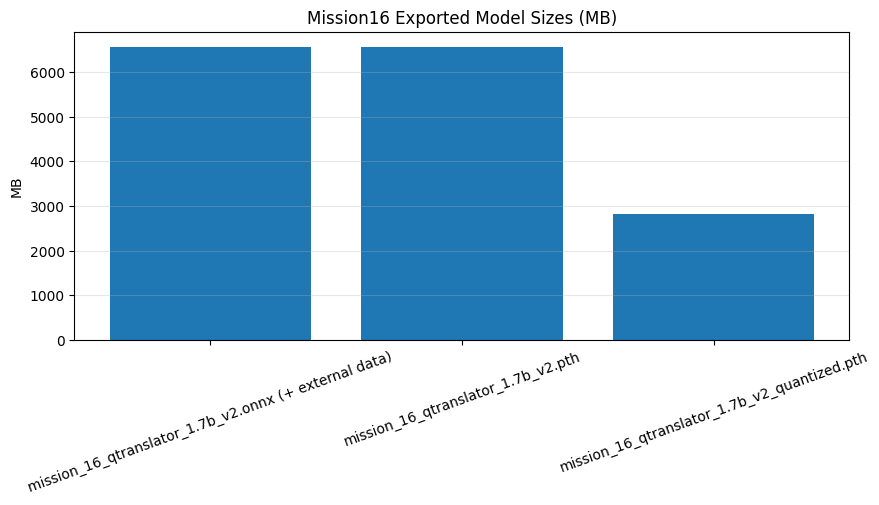

Saved image: /home/hosung/pytorch-demo/Mission_Archive/Codeit_Mission/models/m16/mission16_model_sizes.png


In [ ]:
plt.figure(figsize=(10, 4))
plt.bar(size_df["file"], size_df["size_mb"])
plt.title("Mission16 Exported Model Sizes (MB)")
plt.ylabel("MB")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

# 캡처 파일 저장
size_image_path = cfg.output_dir / "mission16_model_sizes.png"
plt.savefig(size_image_path, dpi=180, bbox_inches="tight")
plt.show()

print("Saved image:", size_image_path)
